CUSTOMER CHURN

In [9]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib 
import matplotlib.pyplot as plot
plot.style.use('ggplot')
from matplotlib .pyplot import figure

In [10]:
#Loading the data which has 5 different sheets
xls = pd.ExcelFile(r"C:/Users/Oscar/Downloads/Customer_Churn_Data_Large.xlsx")
demo = pd.read_excel(xls, 'Customer_Demographics')
trans = pd.read_excel(xls, 'Transaction_History')
service = pd.read_excel(xls, 'Customer_Service')
online = pd.read_excel(xls, 'Online_Activity')
churn = pd.read_excel(xls, 'Churn_Status')

In [11]:
#Combining the sheets
data = demo.merge(trans, on='CustomerID') \
           .merge(service, on='CustomerID') \
           .merge(online, on='CustomerID') \
           .merge(churn, on='CustomerID')

In [12]:
data.shape

(5204, 17)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   object        
 3   MaritalStatus     5204 non-null   object        
 4   IncomeLevel       5204 non-null   object        
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[ns]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   object        
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[ns]
 11  InteractionType   5204 non-null   object        
 12  ResolutionStatus  5204 non-null   object        
 13  LastLoginDate     5204 non-null   datetime64[ns]
 14  LoginFrequency    5204 n

In [14]:
#Descriptive Analysis
data.describe()

,CustomerID,Age,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,ChurnStatus
count,5204.000000,5204.000000,5204.000000,5204,5204.000000,5204.000000,5204,5204,5204.000000,5204.000000
mean,496.470407,43.140085,5495.988470,2022-06-29 08:30:15.219062272,254.354940,5921.861261,2022-07-01 16:31:10.561106944,2023-07-04 09:27:31.960030720,25.918332,0.205995
min,1.000000,18.000000,1000.000000,2022-01-01 00:00:00,5.180000,2015.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,1.000000,0.000000
25%,244.000000,29.000000,3218.000000,2022-03-30 00:00:00,128.940000,3873.250000,2022-04-07 00:00:00,2023-04-04 00:00:00,14.000000,0.000000
50%,504.000000,43.000000,5490.000000,2022-06-27 00:00:00,255.175000,5903.000000,2022-07-02 00:00:00,2023-07-11 00:00:00,27.000000,0.000000
75%,743.000000,57.000000,7713.000000,2022-09-28 00:00:00,378.605000,7851.000000,2022-09-25 00:00:00,2023-10-01 00:00:00,38.000000,0.000000
max,995.000000,69.000000,9997.000000,2022-12-31 00:00:00,499.700000,9997.000000,2022-12-30 00:00:00,2023-12-31 00:00:00,49.000000,1.000000
std,286.681289,15.430343,2595.575295,NaN,143.329654,2332.331260,NaN,NaN,14.110627,0.404466


In [15]:
#Checking for missing data
data.isnull().sum()

CustomerID          0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
TransactionID       0
TransactionDate     0
AmountSpent         0
ProductCategory     0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

In [16]:
data.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


In [17]:
#Feature Engineering;Create age bins
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
data['Age'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

In [18]:
age_counts = data['Age'].value_counts().sort_index()

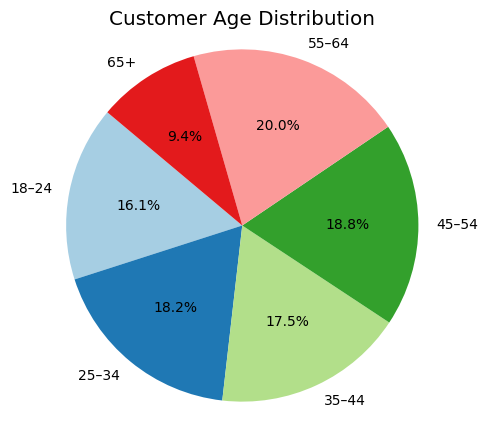

In [19]:
#Plot pie chart
plot.figure(figsize=(5, 5))
plot.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=plot.cm.Paired.colors)
plot.title('Customer Age Distribution')
plot.axis('equal')
plot.show()


In [20]:
#Data Integration
data2 = pd.merge(demo, churn, on='CustomerID')

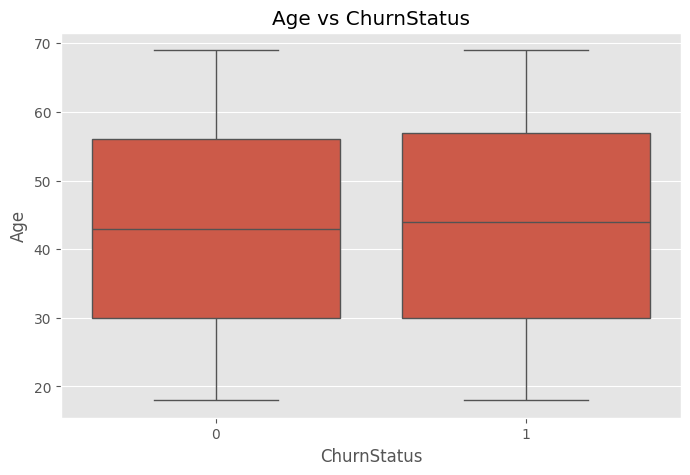

In [21]:
plot.figure(figsize=(8, 5))
sns.boxplot(data=data2, x='ChurnStatus', y='Age')
plot.title('Age vs ChurnStatus')
plot.show()

In [22]:
data2['ChurnStatus'].value_counts()

ChurnStatus
0    796
1    204
Name: count, dtype: int64

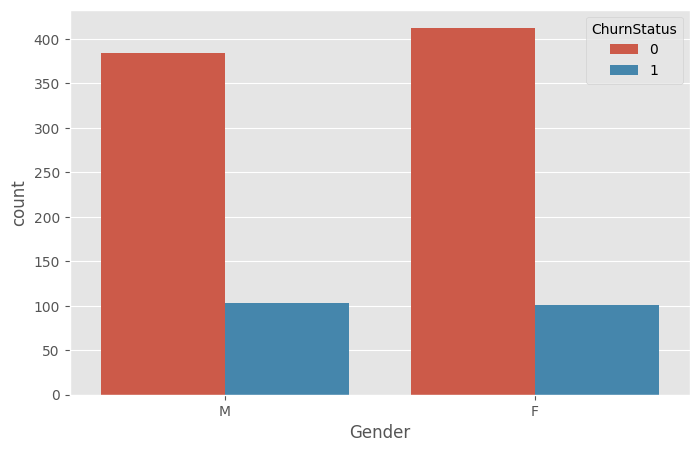

In [23]:
plot.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='ChurnStatus', data=data2)
plot.show()

In [24]:
#Drop columns that are just IDs or not directly useful
data_cleaned = data.drop(['CustomerID', 'TransactionID', 'TransactionDate', 
                      'InteractionID', 'InteractionDate', 'LastLoginDate', 'ProductCategory'], axis=1)
data_cleaned.head()

,Age,Gender,MaritalStatus,IncomeLevel,AmountSpent,InteractionType,ResolutionStatus,LoginFrequency,ServiceUsage,ChurnStatus
0,55–64,M,Single,Low,416.50,Inquiry,Resolved,34,Mobile App,0
1,65+,M,Married,Low,54.96,Inquiry,Resolved,5,Website,1
2,65+,M,Married,Low,197.50,Inquiry,Resolved,5,Website,1
3,65+,M,Married,Low,101.31,Inquiry,Resolved,5,Website,1
4,65+,M,Married,Low,397.37,Inquiry,Resolved,5,Website,1


In [25]:
data_cleaned.shape

(5204, 10)

In [26]:
data_cleaned.describe()

,AmountSpent,LoginFrequency,ChurnStatus
count,5204.000000,5204.000000,5204.000000
mean,254.354940,25.918332,0.205995
std,143.329654,14.110627,0.404466
min,5.180000,1.000000,0.000000
25%,128.940000,14.000000,0.000000
50%,255.175000,27.000000,0.000000
75%,378.605000,38.000000,0.000000
max,499.700000,49.000000,1.000000


In [27]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               5204 non-null   category
 1   Gender            5204 non-null   object  
 2   MaritalStatus     5204 non-null   object  
 3   IncomeLevel       5204 non-null   object  
 4   AmountSpent       5204 non-null   float64 
 5   InteractionType   5204 non-null   object  
 6   ResolutionStatus  5204 non-null   object  
 7   LoginFrequency    5204 non-null   int64   
 8   ServiceUsage      5204 non-null   object  
 9   ChurnStatus       5204 non-null   int64   
dtypes: category(1), float64(1), int64(2), object(6)
memory usage: 371.3+ KB


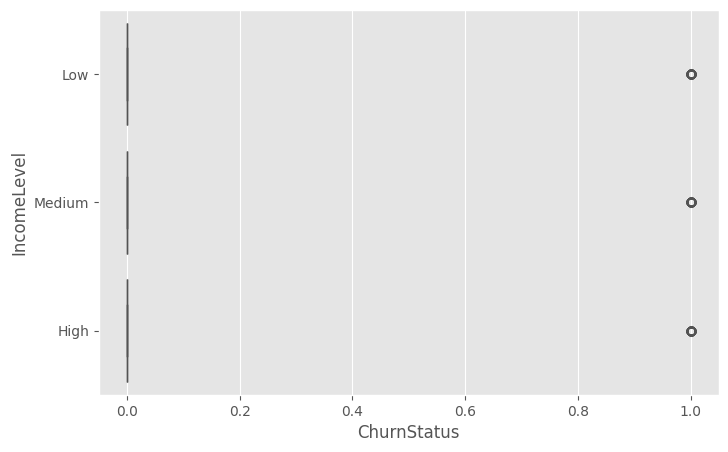

In [28]:
plot.figure(figsize=(8, 5))
sns.boxplot(x='ChurnStatus', y='IncomeLevel', data=data2)
plot.show()

In [29]:
data_cleaned.isnull().sum()

Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
AmountSpent         0
InteractionType     0
ResolutionStatus    0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

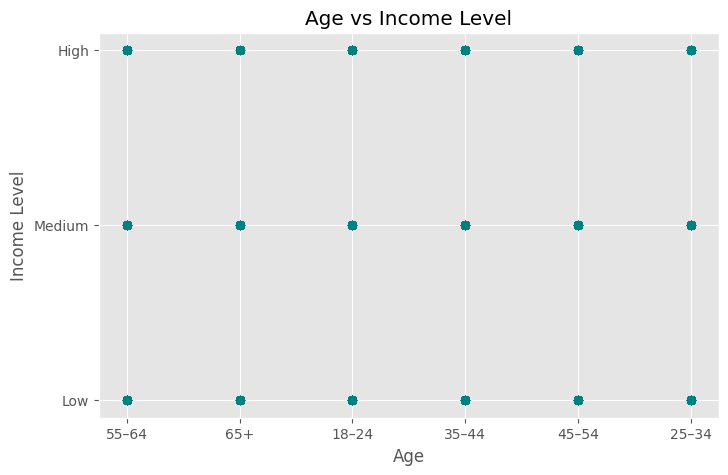

In [30]:
plot.figure(figsize=(8,5))
plot.scatter(data_cleaned['Age'], data['IncomeLevel'], alpha=0.7, color='teal')
plot.title('Age vs Income Level')
plot.xlabel('Age')
plot.ylabel('Income Level')
plot.grid(True)
plot.show()

In [31]:
data_cleaned.select_dtypes( include = 'number').corr()

,AmountSpent,LoginFrequency,ChurnStatus
AmountSpent,1.000000,0.034658,-0.000230
LoginFrequency,0.034658,1.000000,-0.096564
ChurnStatus,-0.000230,-0.096564,1.000000


<Axes: >

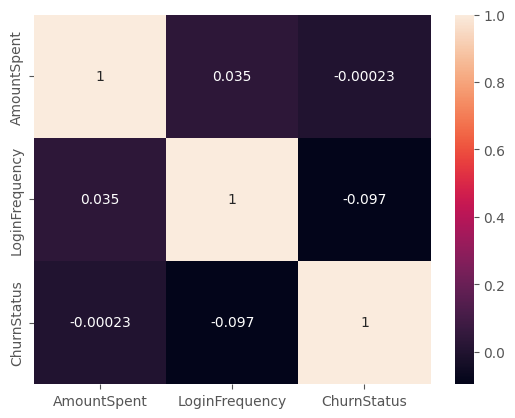

In [32]:
sns.heatmap(data_cleaned.select_dtypes( include = 'number').corr(),annot=True)

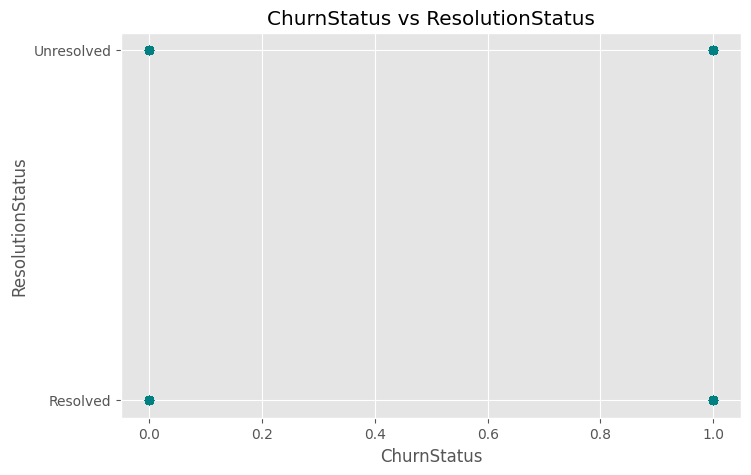

In [33]:
plot.figure(figsize=(8,5))
plot.scatter(data_cleaned['ChurnStatus'], data['ResolutionStatus'], alpha=0.7, color='teal')
plot.title('ChurnStatus vs ResolutionStatus')
plot.xlabel('ChurnStatus')
plot.ylabel('ResolutionStatus')
plot.grid(True)
plot.show()


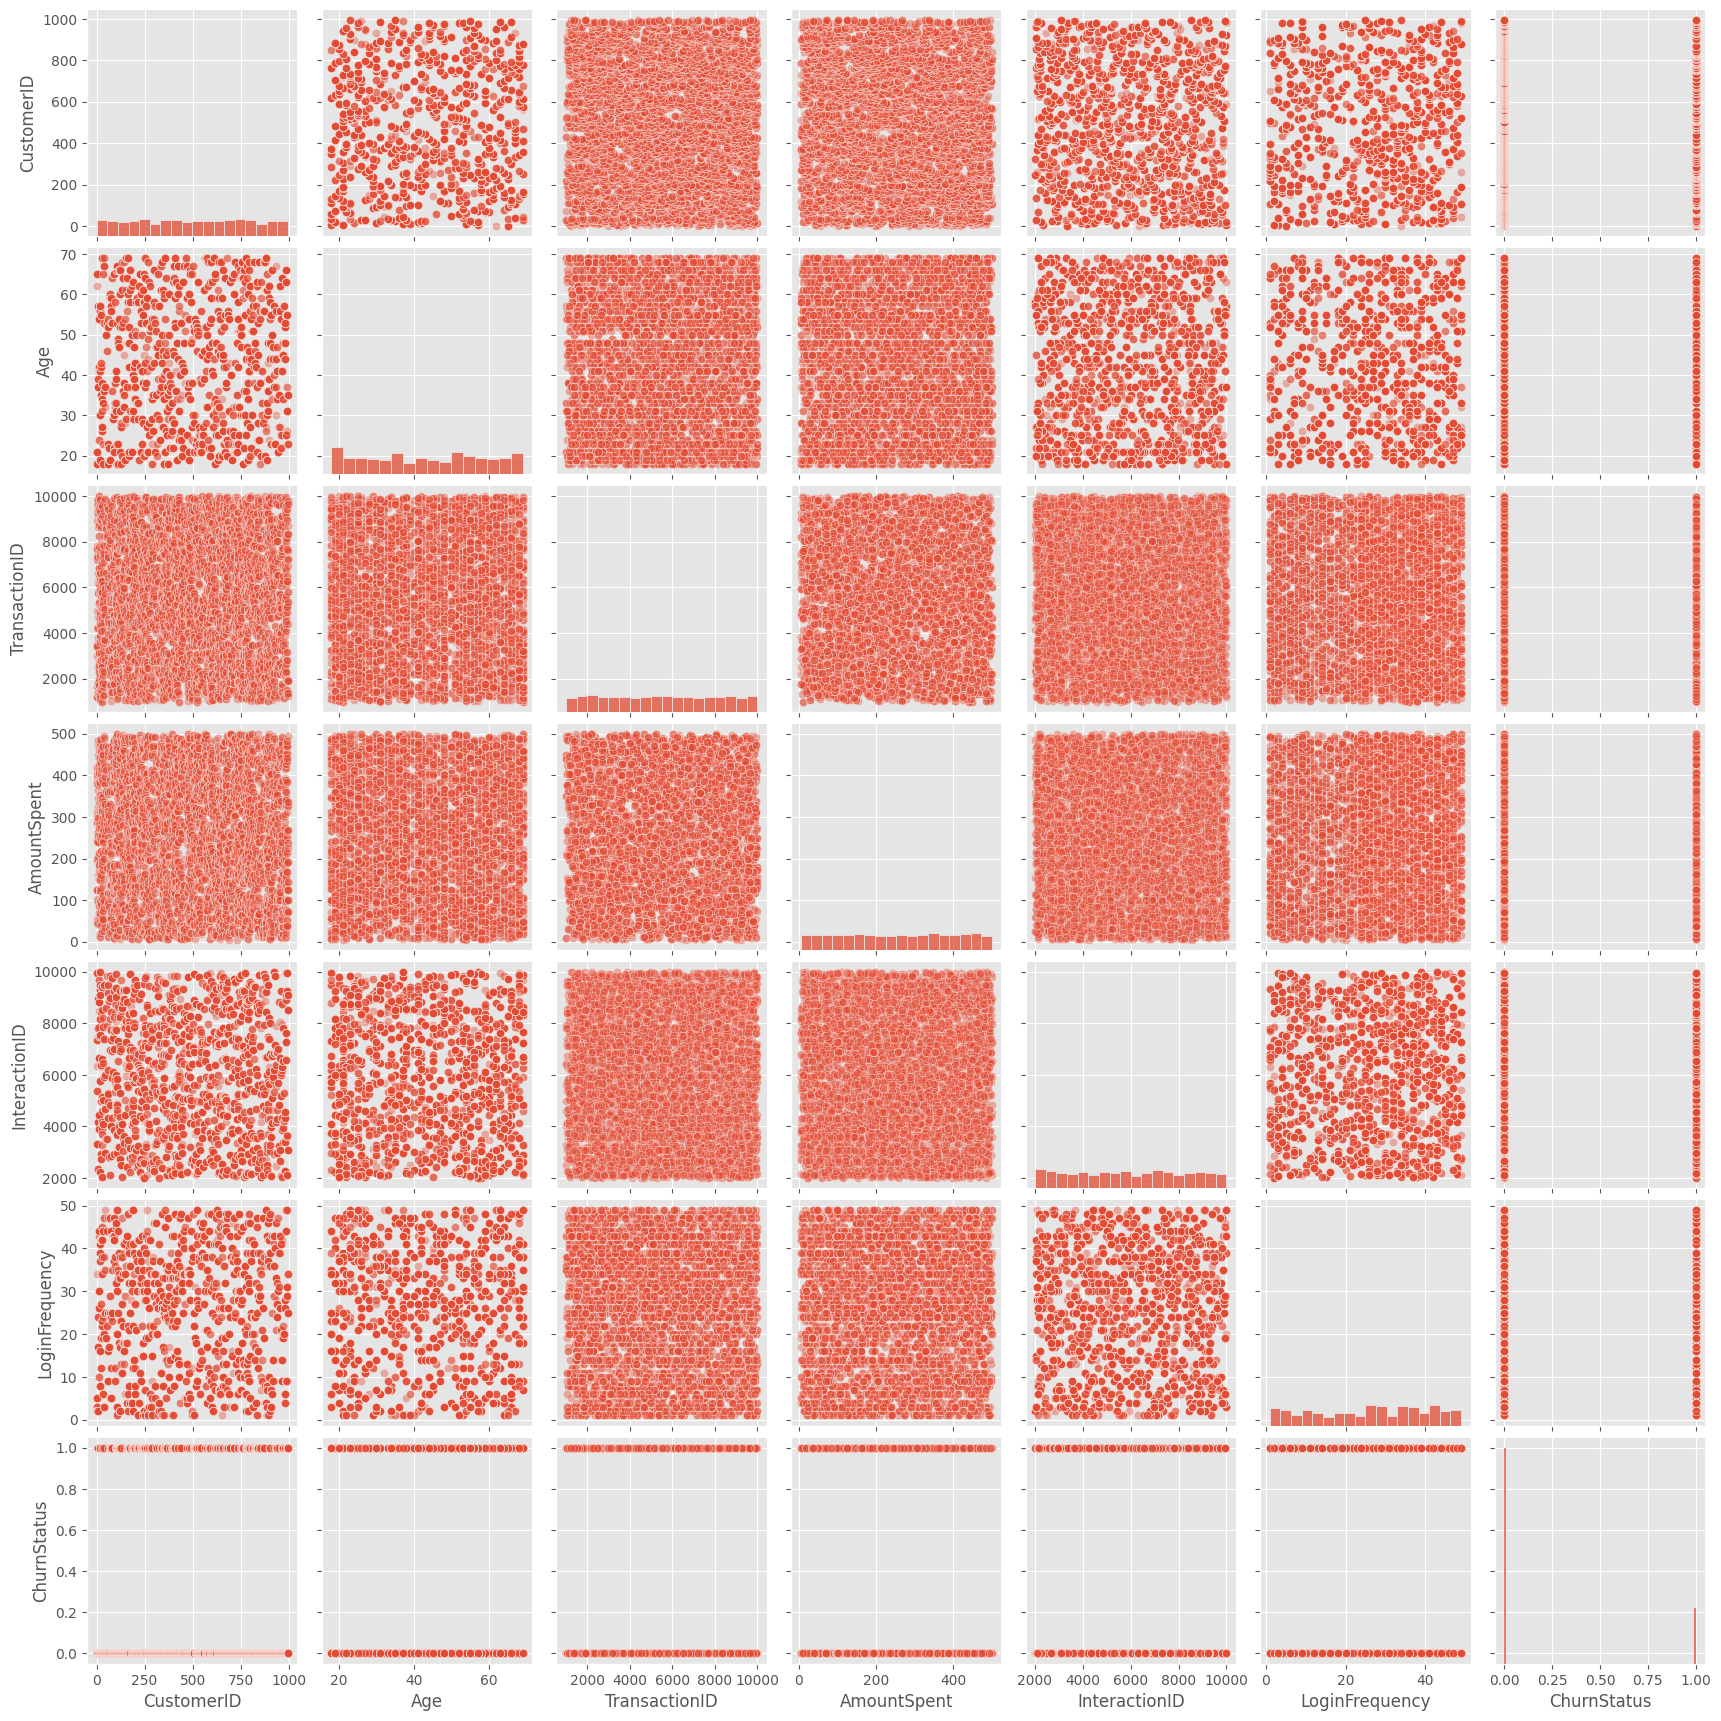

In [54]:
sns.pairplot(data, kind='scatter', plot_kws={'alpha': 0.4})
plot.show()

In [34]:
data = demo.merge(trans, on='CustomerID') \
           .merge(service, on='CustomerID') \
           .merge(online, on='CustomerID') \
           .merge(churn, on='CustomerID')

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [43]:
X = data.drop('ChurnStatus', axis=1)  
y = data['ChurnStatus']


In [44]:
# Encode categorical columns in X
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


In [48]:
# Drop datetime columns
X = X.select_dtypes(exclude=['datetime', 'datetime64[ns]'])


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_proba = rf.predict_proba(X_test)[:, 1]   

In [51]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)


AUC: 0.9979165493552565
